In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("adult_income.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df = df.replace("?", np.nan)

df = df.dropna()

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (30162, 15)


In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "str":

        df[col] = encoder.fit_transform(df[col])

print("Encoding completed")

Encoding completed


In [5]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0


In [6]:
X = df.drop("income", axis=1)

y = df["income"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (30162, 14)
y Shape: (30162,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24129, 14)
Testing Data: (6033, 14)


In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [9]:
y_pred = model.predict(X_test)

print("Predictions generated successfully")

Predictions generated successfully


In [10]:
print(df["sex"].value_counts())

sex
1    20380
0     9782
Name: count, dtype: int64


In [11]:
group_0 = X_test["sex"] == 0
group_1 = X_test["sex"] == 1

acc_group_0 = accuracy_score(
    y_test[group_0],
    y_pred[group_0]
)

acc_group_1 = accuracy_score(
    y_test[group_1],
    y_pred[group_1]
)

fairness_gap = abs(
    acc_group_0 - acc_group_1
)

print("Group 0 Accuracy:", acc_group_0)
print("Group 1 Accuracy:", acc_group_1)
print("Fairness Gap:", fairness_gap)

Group 0 Accuracy: 0.9307036247334755
Group 1 Accuracy: 0.8097185470291075
Fairness Gap: 0.12098507770436795


In [12]:
fairness_table = pd.DataFrame({

    "Metric": [
        "Group_0_Accuracy",
        "Group_1_Accuracy",
        "Fairness_Gap"
    ],

    "Value": [
        acc_group_0,
        acc_group_1,
        fairness_gap
    ]
})

fairness_table

,Metric,Value
0,Group_0_Accuracy,0.930704
1,Group_1_Accuracy,0.809719
2,Fairness_Gap,0.120985


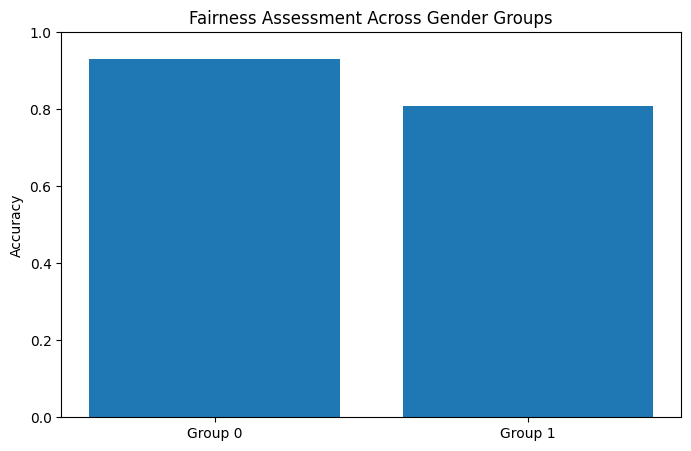

In [13]:
plt.figure(figsize=(8,5))

groups = ["Group 0", "Group 1"]

accuracies = [
    acc_group_0,
    acc_group_1
]

plt.bar(
    groups,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("Fairness Assessment Across Gender Groups")

plt.ylim(0,1)

plt.show()

In [14]:
plt.figure(figsize=(8,5))

groups = ["Group 0", "Group 1"]

accuracies = [
    acc_group_0,
    acc_group_1
]

plt.bar(
    groups,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("Fairness Assessment Across Gender Groups")

plt.ylim(0,1)

plt.savefig(
    "results/RQ3_Fairness.pdf",
    bbox_inches="tight"
)

plt.close()

print("RQ3_Fairness.pdf saved successfully")

RQ3_Fairness.pdf saved successfully


In [15]:
fairness_table.to_csv(
    "results/RQ3_Fairness_Table.csv",
    index=False
)

print("RQ3_Fairness_Table.csv saved successfully")

RQ3_Fairness_Table.csv saved successfully


In [16]:
import os

os.listdir("results")

['RQ2_SHAP_Table.csv',
 'RQ3_Fairness.pdf',
 'RQ2_SHAP.pdf',
 'RQ1_Metrics.csv',
 'RQ1_RadarChart.pdf',
 'RQ3_Fairness_Table.csv']